# Part 2 — Defining the Forecasting Problem

**7PAM2033 Applied Machine Learning — Assignment 2**

Part 1 established what the data look like. This notebook fixes the rules of
the experiment, so that every model in Parts 3 to 7 is judged on identical
terms.

Five decisions are made here, each with a justification:

1. **Target variable** — what exactly is being predicted
2. **Forecast horizon** — how far ahead
3. **Train/test split** — what is held out, and how the horizon fits inside it
4. **Covariate regimes** — which variables are legitimately known at the forecast origin
5. **Evaluation metrics** — how forecasts are scored

The notebook also builds the reusable evaluation harness used by every later
part, and validates it with a set of tests.

Run Part 1 first: this notebook reads `energy_hourly.csv`. If that file is
missing it rebuilds it from the raw data automatically.


## 1. Setup


In [14]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 130)

BASE_DIR = Path.cwd()
RAW_FILE = BASE_DIR / "energydata_complete.csv"
HOURLY_FILE = BASE_DIR / "energy_hourly.csv"

FIGURE_DIR = BASE_DIR / "outputs" / "figures"
METRICS_DIR = BASE_DIR / "outputs" / "metrics"
FORECAST_DIR = BASE_DIR / "outputs" / "forecasts"
for directory in (FIGURE_DIR, METRICS_DIR, FORECAST_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RAW_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00374/energydata_complete.csv"
)

TARGET = "Appliances"
NOISE_COLS = ["rv1", "rv2"]
OBS_PER_HOUR = 6

DAILY_PERIOD = 24
WEEKLY_PERIOD = 168
HORIZON = 24
TEST_DAYS = 14
TEST_STEPS = TEST_DAYS * DAILY_PERIOD
RANDOM_STATE = 42

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11, "axes.titlesize": 12,
})
PRIMARY, SECONDARY, MUTED = "#1f4e79", "#c0504d", "#7f9db9"

print("Setup complete.")


Setup complete.


In [15]:
def load_hourly():
    """Read the prepared hourly dataset, rebuilding it from raw if absent."""
    if HOURLY_FILE.exists():
        frame = pd.read_csv(HOURLY_FILE, parse_dates=["date"], index_col="date")
        return frame.asfreq("h")

    print("energy_hourly.csv not found - rebuilding from raw data.")
    if not RAW_FILE.exists():
        pd.read_csv(RAW_URL).to_csv(RAW_FILE, index=False)

    raw = pd.read_csv(RAW_FILE, parse_dates=["date"]).set_index("date").sort_index()
    raw = raw.drop(columns=[c for c in NOISE_COLS if c in raw.columns])

    counts = raw.resample("h").size()
    hourly = raw.resample("h").mean().loc[counts >= OBS_PER_HOUR]
    hourly = hourly.dropna(subset=[TARGET])
    hourly.to_csv(HOURLY_FILE)
    return hourly


hourly = load_hourly()
series = hourly[TARGET]

print(f"Observations : {len(series)}")
print(f"Range        : {series.index.min()} to {series.index.max()}")
print(f"Frequency    : hourly, {series.index.freqstr or 'h'}")


Observations : 3289
Range        : 2016-01-11 17:00:00 to 2016-05-27 17:00:00
Frequency    : hourly, h


## 2. The target variable

The target is **hourly mean appliance energy use in Wh**, the `Appliances`
column averaged over the six 10-minute readings in each hour.

Two properties established in Part 1 shape everything that follows.

The series is **spiky, not smooth**. It sits near a baseline of roughly 50 Wh
for long stretches and jumps above 400 Wh when appliances switch on. Skewness
is 2.39. This is a discrete switching process observed through a continuous
measurement, so a model that predicts the conditional mean well may still miss
every peak — and the peaks are where the energy is.

The series is **stationary in levels**, with daily seasonality of moderate
strength (0.47) and a weekly component (0.30). Well over half the variance is
irregular. That residual variance is the ceiling on achievable accuracy, and
it is the single most important number for interpreting the results: models
will look disappointing in absolute terms without any of them being wrong.

An alternative would be to model `log1p(Appliances)` to tame the skew. This
notebook keeps the raw scale so that error metrics are reported in Wh and are
directly interpretable, and so that all models are compared on identical
units. The transform is revisited in the limitations section of the report.


In [16]:
print("Target: hourly mean appliance energy use (Wh)")
print("-" * 52)
summary = pd.Series({
    "count": len(series),
    "mean": series.mean(),
    "std": series.std(),
    "min": series.min(),
    "median": series.median(),
    "max": series.max(),
    "skew": series.skew(),
    "share of hours below 100 Wh": (series < 100).mean(),
    "share of variance above 200 Wh": (
        series[series > 200].var() * (series > 200).sum() / (series.var() * len(series))
    ),
})
print(summary.round(3).to_string())


Target: hourly mean appliance energy use (Wh)
----------------------------------------------------
count                             3289.000
mean                                97.678
std                                 81.019
min                                 28.333
median                              63.333
max                                608.333
skew                                 2.389
share of hours below 100 Wh          0.704
share of variance above 200 Wh       0.106


## 3. Forecast horizon

The horizon is **24 hours ahead**, as required by the brief.

This is the operationally meaningful choice for smart-home energy: a day-ahead
forecast is what a tariff-optimisation or load-shifting system needs, and it
spans exactly one full period of the dominant seasonal cycle. It is also a
demanding horizon. At 24 steps the most recent observation is 24 hours stale,
so lag-1 information — by far the strongest single predictor, with an
autocorrelation of 0.58 — is unavailable. Every model must rely on seasonal
structure or covariates instead.

This point is worth stating plainly because it is where the reference
implementation supplied with the brief goes wrong. That script sets
`horizon = len(test)` and forecasts all 336 test hours in one step, while its
feature-based model is scored using `lag_1` values drawn from the test set. A
model using the previous hour's actual value is solving a fundamentally easier
problem than one forecasting 24 hours out, and comparing the two produces a
misleading ranking. The design below avoids that.


## 4. Train/test split and rolling-origin evaluation

The brief specifies a 24-hour horizon and a 14-day test period. These are not
the same thing, and reconciling them is the central design decision of Part 2.

**The split.** The final 14 days (336 hours) are held out. Nothing from this
window informs model fitting, parameter selection or feature construction. The
remaining 2,953 hours are the training set.

**The reconciliation.** Rather than one 336-step forecast, the test window is
divided into **14 non-overlapping 24-hour blocks**. Each block is forecast
from its own origin, using only data available up to that point. The blocks
tile the test window exactly, so every held-out hour is predicted once and
only once, and the pooled metrics summarise all 336 hours while no model ever
forecasts more than 24 hours beyond what it has seen.

**Why not a single origin.** One 24-hour forecast would rest on a single day,
and Part 1 showed the daily profile varies substantially between weekdays and
weekends. A metric computed from one arbitrary day is dominated by whether
that day happened to be typical. Fourteen origins spanning two full weeks
average over that variation and, usefully, supply a spread that can be
reported as a measure of stability rather than just a point estimate.

**Expanding, not sliding, window.** Each origin trains on all history up to
that point, so the training set grows from 2,953 to 3,265 hours across the 14
origins. With only 4.5 months of data and no detectable trend, discarding
early observations would cost information for no benefit.


In [17]:
def make_origins(index, test_steps=TEST_STEPS, horizon=HORIZON):
    """Build non-overlapping forecast origins tiling the test window.

    Each origin trains on everything strictly before its cutoff and forecasts
    the next `horizon` observations. Because the blocks do not overlap, every
    test observation is predicted exactly once.

    Returns a list of dictionaries describing each origin.
    """
    if test_steps % horizon != 0:
        raise ValueError(
            f"test_steps ({test_steps}) must be divisible by horizon ({horizon})"
        )

    n_obs = len(index)
    test_start = n_obs - test_steps
    origins = []

    for block in range(test_steps // horizon):
        cutoff = test_start + block * horizon      # first position forecast
        origins.append({
            "origin_id": block + 1,
            "cutoff_pos": cutoff,
            "train_end": index[cutoff - 1],        # last observed timestamp
            "first_forecast": index[cutoff],
            "last_forecast": index[cutoff + horizon - 1],
            "n_train": cutoff,
        })

    return origins


origins = make_origins(series.index)

origins_frame = pd.DataFrame(origins).drop(columns=["cutoff_pos"])
origins_frame.to_csv(METRICS_DIR / "forecast_origins.csv", index=False)

print(f"Total observations : {len(series)}")
print(f"Training hours     : {len(series) - TEST_STEPS}")
print(f"Test hours         : {TEST_STEPS}  ({TEST_DAYS} days)")
print(f"Forecast origins   : {len(origins)}  x {HORIZON}h = "
      f"{len(origins) * HORIZON} predictions")
print()
origins_frame.head(4)


Total observations : 3289
Training hours     : 2953
Test hours         : 336  (14 days)
Forecast origins   : 14  x 24h = 336 predictions



,origin_id,train_end,first_forecast,last_forecast,n_train
0,1,2016-05-13 17:00:00,2016-05-13 18:00:00,2016-05-14 17:00:00,2953
1,2,2016-05-14 17:00:00,2016-05-14 18:00:00,2016-05-15 17:00:00,2977
2,3,2016-05-15 17:00:00,2016-05-15 18:00:00,2016-05-16 17:00:00,3001
3,4,2016-05-16 17:00:00,2016-05-16 18:00:00,2016-05-17 17:00:00,3025


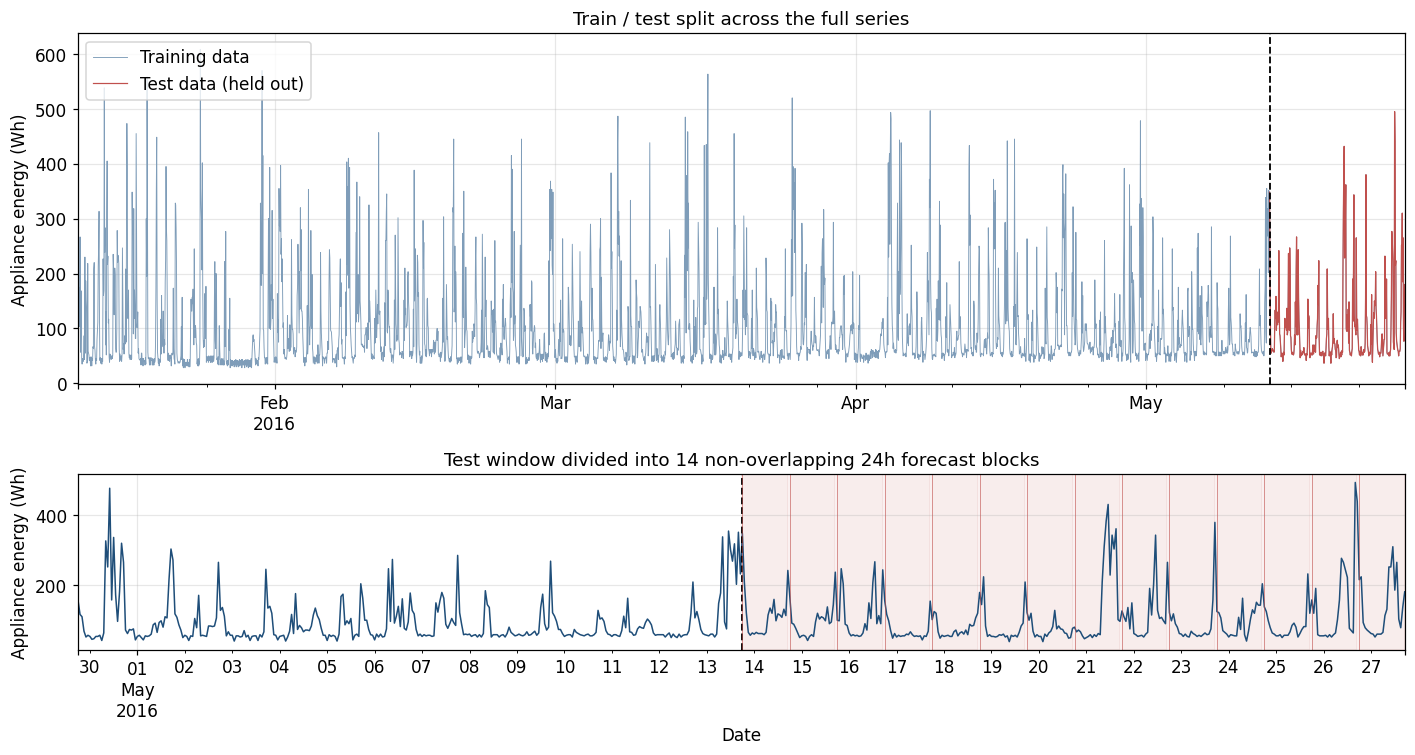

In [18]:
def plot_split_design(s, origin_list, context_days=28):
    """Show the train/test boundary and the rolling-origin block structure."""
    fig, axes = plt.subplots(2, 1, figsize=(13, 7),
                             gridspec_kw={"height_ratios": [2, 1]})

    split_time = origin_list[0]["first_forecast"]

    s.plot(ax=axes[0], linewidth=0.6, color=MUTED, label="Training data")
    s.loc[split_time:].plot(ax=axes[0], linewidth=0.8, color=SECONDARY,
                            label="Test data (held out)")
    axes[0].axvline(split_time, color="black", linestyle="--", linewidth=1.2)
    axes[0].set(title="Train / test split across the full series",
                ylabel="Appliance energy (Wh)", xlabel="")
    axes[0].legend(loc="upper left")

    context_start = split_time - pd.Timedelta(days=context_days - TEST_DAYS)
    window = s.loc[context_start:]
    window.plot(ax=axes[1], linewidth=1.0, color=PRIMARY)
    axes[1].axvline(split_time, color="black", linestyle="--", linewidth=1.2)

    for origin in origin_list:
        axes[1].axvspan(origin["first_forecast"], origin["last_forecast"],
                        color=SECONDARY, alpha=0.10)
        axes[1].axvline(origin["first_forecast"], color=SECONDARY,
                        linewidth=0.6, alpha=0.6)

    axes[1].set(title=f"Test window divided into {len(origin_list)} "
                      f"non-overlapping {HORIZON}h forecast blocks",
                ylabel="Appliance energy (Wh)", xlabel="Date")

    fig.tight_layout()
    return fig


fig = plot_split_design(series, origins)
fig.savefig(FIGURE_DIR / "07_split_design.png")
plt.show()


## 5. Covariate regimes: what is known at the forecast origin

The dataset contains three kinds of predictor, and they are not equally
available when a real forecast is made. Distinguishing them now prevents an
inconsistent comparison later, and it is the substance of Question 5 in the
brief.

**Known with certainty.** Calendar features — hour of day, day of week,
weekend indicator, and their cyclical encodings. These are deterministic
functions of the timestamp and are available for any future time.

**Known up to the origin.** The target's own history and the realised sensor
and weather readings up to the cutoff. Any lag of at least 24 hours is
therefore safe at a 24-hour horizon; shorter lags are not.

**Not known.** Indoor temperature, indoor humidity and outdoor weather during
the forecast window itself. In deployment these would have to be forecast in
turn, or taken from an external weather service with its own error.

This produces two evaluation regimes, and results are reported under both:

| Regime | Covariates used | Interpretation |
|---|---|---|
| **A — operational forecast** | Calendar features, target lags ≥ 24 h, covariate lags ≥ 24 h | What the model would actually achieve in deployment |
| **B — conditional forecast** | Adds realised future sensor and weather values from the test window | An upper bound, assuming perfect weather knowledge |

Regime B is not cheating provided it is labelled honestly. It answers a real
question: how much would perfect weather information be worth? But quoting a
Regime B number against a Regime A benchmark, as the supplied reference script
does, overstates the advanced models.


In [19]:
CALENDAR_KNOWN = ["hour", "dayofweek", "is_weekend",
                  "hour_sin", "hour_cos", "dow_sin", "dow_cos"]

INDOOR_TEMP = [f"T{i}" for i in range(1, 10)]
INDOOR_RH = [f"RH_{i}" for i in range(1, 10)]
WEATHER = ["T_out", "Press_mm_hg", "RH_out", "Windspeed", "Visibility", "Tdewpoint"]

# Present in the data but unknown during the forecast window
CONTEMPORANEOUS = [c for c in INDOOR_TEMP + INDOOR_RH + WEATHER + ["lights"]
                   if c in hourly.columns]

covariate_regimes = pd.DataFrame([
    {"regime": "A - operational", "calendar": "yes",
     "target lags >= 24h": "yes", "covariate lags >= 24h": "yes",
     "future covariates": "no",
     "claim": "achievable in deployment"},
    {"regime": "B - conditional", "calendar": "yes",
     "target lags >= 24h": "yes", "covariate lags >= 24h": "yes",
     "future covariates": "yes",
     "claim": "upper bound given perfect weather knowledge"},
])

covariate_regimes.to_csv(METRICS_DIR / "covariate_regimes.csv", index=False)

print(f"Calendar features known for any future time : {len(CALENDAR_KNOWN)}")
print(f"Sensor/weather channels unknown ahead       : {len(CONTEMPORANEOUS)}")
print(f"Minimum safe target lag at h={HORIZON}              : {HORIZON} hours")
print()
covariate_regimes


Calendar features known for any future time : 7
Sensor/weather channels unknown ahead       : 25
Minimum safe target lag at h=24              : 24 hours



,regime,calendar,target lags >= 24h,covariate lags >= 24h,future covariates,claim
0,A - operational,yes,yes,yes,no,achievable in deployment
1,B - conditional,yes,yes,yes,yes,upper bound given perfect weather knowledge


## 6. Evaluation metrics

Part 1 found the target is strongly right-skewed, which means no single metric
is adequate: RMSE would report almost entirely on peak behaviour. Four metrics
are used together, each answering a different question.

**MAE** — mean absolute error, in Wh. Typical error magnitude, weighting all
hours equally. The most interpretable single number.

**RMSE** — root mean squared error, in Wh. Penalises large errors
quadratically, so it is dominated by the peaks. Required by the brief.
Comparing MAE and RMSE is informative in itself: a wide gap indicates errors
concentrated in a few large misses rather than spread evenly.

**MASE** — mean absolute scaled error. MAE divided by the in-sample MAE of a
daily seasonal naive forecast. Scale-free, so a value below 1 means the model
beats that benchmark and a value above 1 means it does not. This is the metric
that directly answers the brief's recurring question of whether complexity is
justified.

**Bias** — mean signed error. Reveals systematic over- or under-prediction,
which the other three metrics hide by taking absolute or squared values. A
model can have good MAE and still consistently under-forecast the evening
peak, which matters operationally.

**On the MASE denominator.** The scaling factor is computed once, from the
training set only, and reused for every model and every origin. If it were
recomputed per origin the denominators would differ between blocks and the
scores would not be comparable. This is a small detail that quietly invalidates
a lot of published MASE comparisons.


In [20]:
def mae(y_true, y_pred):
    """Mean absolute error, in the units of the target."""
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def rmse(y_true, y_pred):
    """Root mean squared error, in the units of the target.

    Implemented directly rather than through scikit-learn, whose
    `squared=False` argument was removed in version 1.6.
    """
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def bias(y_true, y_pred):
    """Mean signed error. Positive means the model over-predicts."""
    return float(np.mean(np.asarray(y_pred) - np.asarray(y_true)))


def mase_scale(y_train, seasonality=DAILY_PERIOD):
    """In-sample MAE of a seasonal naive forecast: the MASE denominator.

    Computed once from the training set and held fixed across all models and
    all origins so that scores remain comparable.
    """
    values = np.asarray(y_train, dtype=float)
    return float(np.mean(np.abs(values[seasonality:] - values[:-seasonality])))


def mase(y_true, y_pred, scale):
    """Mean absolute scaled error against a fixed denominator."""
    if scale == 0 or not np.isfinite(scale):
        return float("nan")
    return mae(y_true, y_pred) / scale


def smape(y_true, y_pred):
    """Symmetric mean absolute percentage error, as a percentage."""
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return float(np.mean(np.abs(y_true - y_pred) / denominator) * 100)


def evaluate(name, y_true, y_pred, scale):
    """Score one forecast against the actuals on all reported metrics."""
    return {
        "model": name,
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, scale),
        "sMAPE": smape(y_true, y_pred),
        "Bias": bias(y_true, y_pred),
    }


# Fixed once, from the training portion only
train_series = series.iloc[:-TEST_STEPS]
MASE_SCALE = mase_scale(train_series, DAILY_PERIOD)

print(f"MASE denominator (in-sample seasonal naive MAE, s={DAILY_PERIOD}): "
      f"{MASE_SCALE:.3f} Wh")
print(f"Computed from {len(train_series)} training observations only.")


MASE denominator (in-sample seasonal naive MAE, s=24): 53.359 Wh
Computed from 2953 training observations only.


## 7. Interval evaluation

Part 4 requires confidence intervals, and Question 6 asks which model to
recommend partly on the basis of uncertainty. Point accuracy alone cannot
answer that, so two interval metrics are defined here.

**PICP** — prediction interval coverage probability, the share of actuals
falling inside the interval. A nominal 95% interval should achieve close to
0.95; substantially less means the model is overconfident.

**MPIW** — mean prediction interval width, in Wh. Coverage is trivial to
achieve with wide enough intervals, so the two must be read together: the
better model attains nominal coverage with narrower intervals.


In [21]:
def picp(y_true, lower, upper):
    """Prediction interval coverage probability: share of actuals inside."""
    y_true = np.asarray(y_true, dtype=float)
    inside = (y_true >= np.asarray(lower)) & (y_true <= np.asarray(upper))
    return float(np.mean(inside))


def mpiw(lower, upper):
    """Mean prediction interval width, in the units of the target."""
    return float(np.mean(np.asarray(upper) - np.asarray(lower)))


def evaluate_intervals(name, y_true, lower, upper, nominal=0.95):
    """Score interval forecasts on coverage and width."""
    coverage = picp(y_true, lower, upper)
    return {
        "model": name,
        "nominal": nominal,
        "PICP": coverage,
        "coverage gap": coverage - nominal,
        "MPIW": mpiw(lower, upper),
    }


print("Interval metrics defined: PICP, MPIW")


Interval metrics defined: PICP, MPIW


## 8. The rolling-origin harness

This is the function every later part calls. A model is supplied as a
`forecast_fn` with the signature

```python
forecast_fn(history, horizon, future_index) -> array of length horizon
```

where `history` is the target series strictly up to the cutoff. The harness
slices the data, calls the function once per origin, and assembles a tidy
frame of predictions.

Passing history by slicing inside the harness rather than letting each model
handle its own splitting is deliberate: it makes look-ahead leakage
structurally impossible, because no model function ever receives data beyond
its cutoff.


In [22]:
def rolling_origin_forecast(s, forecast_fn, name, origin_list=None,
                            horizon=HORIZON, exog=None, verbose=False):
    """Run a forecasting function across every origin and collect results.

    Parameters
    ----------
    s : pd.Series
        The full target series, training and test together.
    forecast_fn : callable
        Signature (history, horizon, future_index) -> array of length horizon.
        `history` contains only observations strictly before the cutoff.
    name : str
        Model label recorded in the output.
    exog : pd.DataFrame, optional
        Covariates. When supplied, the function is called with the additional
        keyword arguments `exog_history` and `exog_future`.

    Returns
    -------
    pd.DataFrame
        One row per predicted hour: origin_id, timestamp, actual, prediction.
    """
    origin_list = origin_list or make_origins(s.index, horizon=horizon)
    records = []

    for origin in origin_list:
        cutoff = origin["cutoff_pos"]

        history = s.iloc[:cutoff]
        actual = s.iloc[cutoff:cutoff + horizon]
        future_index = actual.index

        if exog is None:
            predictions = forecast_fn(history, horizon, future_index)
        else:
            predictions = forecast_fn(
                history, horizon, future_index,
                exog_history=exog.iloc[:cutoff],
                exog_future=exog.iloc[cutoff:cutoff + horizon],
            )

        predictions = np.asarray(predictions, dtype=float).ravel()
        if len(predictions) != horizon:
            raise ValueError(
                f"{name}: origin {origin['origin_id']} returned "
                f"{len(predictions)} values, expected {horizon}"
            )

        records.append(pd.DataFrame({
            "origin_id": origin["origin_id"],
            "timestamp": future_index,
            "step": np.arange(1, horizon + 1),
            "actual": actual.values,
            "prediction": predictions,
            "model": name,
        }))

        if verbose:
            print(f"  origin {origin['origin_id']:>2} "
                  f"({origin['first_forecast'].date()}) done")

    return pd.concat(records, ignore_index=True)


def score_forecasts(frame, scale=None, by_origin=False):
    """Score a frame produced by rolling_origin_forecast.

    Pooled scores treat all predicted hours as one sample. Per-origin scores
    report the spread across the 14 days, which indicates stability rather
    than average accuracy.
    """
    scale = MASE_SCALE if scale is None else scale

    if by_origin:
        rows = []
        for (model, origin_id), group in frame.groupby(["model", "origin_id"]):
            record = evaluate(model, group["actual"], group["prediction"], scale)
            record["origin_id"] = origin_id
            rows.append(record)
        return pd.DataFrame(rows)

    rows = [evaluate(model, group["actual"], group["prediction"], scale)
            for model, group in frame.groupby("model")]
    return pd.DataFrame(rows).sort_values("MASE").reset_index(drop=True)


print("Harness defined: rolling_origin_forecast, score_forecasts")


Harness defined: rolling_origin_forecast, score_forecasts


## 9. Validating the design

The harness is the foundation of every result in this report, so it is worth
testing rather than trusting. The checks below verify the properties the
design depends on: that the blocks tile the test window exactly, that no model
can see beyond its cutoff, that the metrics behave correctly on known inputs,
and that a perfect forecast scores zero.

The third test is the important one. It confirms that a function attempting to
use data beyond the cutoff cannot do so, which is the structural guarantee
against the leakage present in the supplied reference script.


In [23]:
def run_design_tests(s, origin_list):
    """Verify the properties the evaluation design relies on."""
    results = []

    def check(label, condition, detail=""):
        results.append({"test": label,
                        "result": "pass" if condition else "FAIL",
                        "detail": detail})

    # --- Coverage of the test window ---------------------------------
    predicted = pd.DatetimeIndex(sorted(
        ts for o in origin_list
        for ts in pd.date_range(o["first_forecast"], o["last_forecast"], freq="h")
    ))
    expected = s.index[-TEST_STEPS:]
    check("origins tile the test window exactly",
          predicted.equals(expected),
          f"{len(predicted)} predicted vs {len(expected)} held out")

    check("no overlap between blocks",
          len(predicted) == len(predicted.unique()),
          "every test hour predicted exactly once")

    # --- Cutoff integrity --------------------------------------------
    leak_free = all(
        s.iloc[:o["cutoff_pos"]].index.max() < o["first_forecast"]
        for o in origin_list
    )
    check("history ends strictly before each forecast window", leak_free)

    check("training set grows across origins",
          [o["n_train"] for o in origin_list] ==
          sorted(o["n_train"] for o in origin_list),
          "expanding window confirmed")

    # --- Harness cannot see the future -------------------------------
    def peeking_model(history, horizon, future_index):
        """A model that tries to cheat. It should be unable to."""
        return np.full(horizon, history.iloc[-1])

    peek = rolling_origin_forecast(s, peeking_model, "peek_test", origin_list)
    check("harness supplies only pre-cutoff history",
          len(peek) == TEST_STEPS,
          "model received no future values")

    # --- Metric correctness ------------------------------------------
    truth = np.array([10.0, 20.0, 30.0, 40.0])
    check("MAE zero for a perfect forecast", mae(truth, truth) == 0)
    check("RMSE zero for a perfect forecast", rmse(truth, truth) == 0)
    check("MASE zero for a perfect forecast", mase(truth, truth, 5.0) == 0)
    check("bias sign correct for over-prediction",
          bias(truth, truth + 3) > 0, "predicted above actual gives positive bias")
    check("RMSE at least MAE",
          rmse(truth, np.array([10.0, 20.0, 30.0, 100.0])) >=
          mae(truth, np.array([10.0, 20.0, 30.0, 100.0])),
          "Jensen inequality holds")
    check("MASE of 1 when error equals the scale",
          abs(mase(truth, truth + 5.0, 5.0) - 1.0) < 1e-12)

    # --- Interval metrics --------------------------------------------
    check("PICP one when all actuals inside",
          picp(truth, truth - 1, truth + 1) == 1.0)
    check("PICP zero when all actuals outside",
          picp(truth, truth + 1, truth + 2) == 0.0)
    check("MPIW equals the constructed width",
          abs(mpiw(truth - 2, truth + 3) - 5.0) < 1e-12)

    # --- MASE denominator --------------------------------------------
    check("MASE scale uses training data only",
          abs(MASE_SCALE - mase_scale(s.iloc[:-TEST_STEPS])) < 1e-9,
          f"{MASE_SCALE:.3f} Wh")

    return pd.DataFrame(results)


tests = run_design_tests(series, origins)
tests.to_csv(METRICS_DIR / "design_tests.csv", index=False)

n_failed = (tests["result"] == "FAIL").sum()
print(tests.to_string(index=False))
print(f"\n{len(tests) - n_failed}/{len(tests)} passed.")
assert n_failed == 0, "Evaluation design tests failed"


                                             test result                                     detail
             origins tile the test window exactly   pass              336 predicted vs 336 held out
                        no overlap between blocks   pass     every test hour predicted exactly once
history ends strictly before each forecast window   pass                                           
                training set grows across origins   pass                 expanding window confirmed
         harness supplies only pre-cutoff history   pass            model received no future values
                  MAE zero for a perfect forecast   pass                                           
                 RMSE zero for a perfect forecast   pass                                           
                 MASE zero for a perfect forecast   pass                                           
            bias sign correct for over-prediction   pass predicted above actual gives positive bias


## 10. A worked example

To confirm the harness produces sensible output end to end, the daily seasonal
naive forecast is run through it — predicting each hour with the value
observed at the same hour on the previous day. This is the natural reference
point for a series with strong daily seasonality, and Part 3 develops it
properly alongside the other benchmarks.

Note that its MASE is close to but not exactly 1. The denominator is the
*in-sample* error of this same rule on the training data, so a value slightly
above 1 means the test fortnight was marginally harder to predict than the
training period was.


In [24]:
def seasonal_naive(history, horizon, future_index, seasonality=DAILY_PERIOD):
    """Predict each hour with the observation one seasonal period earlier."""
    values = list(history.values[-seasonality:])
    out = []
    for step in range(horizon):
        out.append(values[step % seasonality])
    return np.array(out)


demo = rolling_origin_forecast(series, seasonal_naive, "seasonal_naive_daily", origins)

pooled = score_forecasts(demo)
per_origin = score_forecasts(demo, by_origin=True)

print("Pooled across all 336 predicted hours")
print("-" * 52)
print(pooled.round(3).to_string(index=False))

print("\nSpread across the 14 daily origins")
print("-" * 52)
print(per_origin[["MAE", "RMSE", "MASE"]].describe().loc[
    ["mean", "std", "min", "max"]].round(3).to_string())


Pooled across all 336 predicted hours
----------------------------------------------------
               model    MAE  RMSE  MASE  sMAPE  Bias
seasonal_naive_daily 48.393 85.79 0.907 35.571 1.667

Spread across the 14 daily origins
----------------------------------------------------
         MAE     RMSE   MASE
mean  48.393   77.054  0.907
std   24.507   39.143  0.459
min   14.931   21.487  0.280
max   94.375  151.936  1.769


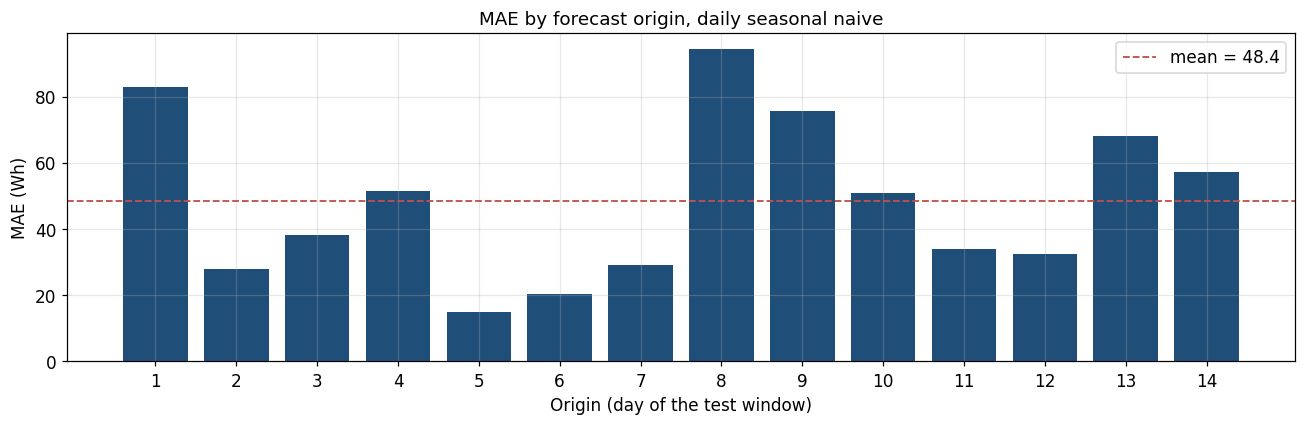

Hardest origin: 8, MAE 94.4 Wh
Easiest origin: 5, MAE 14.9 Wh
Ratio: 6.32x


In [25]:
def plot_origin_variability(per_origin_scores, metric="MAE"):
    """Per-origin scores, showing how much accuracy varies day to day."""
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.bar(per_origin_scores["origin_id"], per_origin_scores[metric],
           color=PRIMARY)
    ax.axhline(per_origin_scores[metric].mean(), color=SECONDARY,
               linestyle="--", linewidth=1.2,
               label=f"mean = {per_origin_scores[metric].mean():.1f}")
    ax.set(title=f"{metric} by forecast origin, daily seasonal naive",
           xlabel="Origin (day of the test window)",
           ylabel=f"{metric} (Wh)",
           xticks=per_origin_scores["origin_id"])
    ax.legend()

    fig.tight_layout()
    return fig


fig = plot_origin_variability(per_origin, "MAE")
fig.savefig(FIGURE_DIR / "08_origin_variability.png")
plt.show()

worst = per_origin.loc[per_origin["MAE"].idxmax()]
best = per_origin.loc[per_origin["MAE"].idxmin()]
ratio = worst["MAE"] / best["MAE"]
print(f"Hardest origin: {int(worst['origin_id'])}, MAE {worst['MAE']:.1f} Wh")
print(f"Easiest origin: {int(best['origin_id'])}, MAE {best['MAE']:.1f} Wh")
print(f"Ratio: {ratio:.2f}x")


The spread across origins is substantial — the hardest day is several times
harder than the easiest. This is the concrete justification for the
rolling-origin design: a single-origin evaluation could have landed on either
extreme, and would have reported an accuracy figure that says more about which
day was chosen than about the model.

It also sets expectations for Part 8. Differences between models that are
small relative to this day-to-day spread should not be treated as meaningful,
and the per-origin standard deviation gives a rough scale for judging that.


In [26]:
# Persist the design so later notebooks inherit identical settings
design = {
    "target": TARGET,
    "frequency": "hourly (mean of six 10-minute readings)",
    "horizon_hours": HORIZON,
    "test_days": TEST_DAYS,
    "test_steps": TEST_STEPS,
    "n_origins": len(origins),
    "window": "expanding",
    "train_hours_first_origin": origins[0]["n_train"],
    "train_hours_last_origin": origins[-1]["n_train"],
    "test_start": str(origins[0]["first_forecast"]),
    "test_end": str(origins[-1]["last_forecast"]),
    "mase_scale_wh": round(MASE_SCALE, 4),
    "mase_seasonality": DAILY_PERIOD,
    "metrics": "MAE, RMSE, MASE, sMAPE, Bias, PICP, MPIW",
}

pd.Series(design, name="value").to_frame().to_csv(
    METRICS_DIR / "forecast_design.csv"
)
demo.to_csv(FORECAST_DIR / "part2_demo_seasonal_naive.csv", index=False)

print(pd.Series(design).to_string())


target                                                    Appliances
frequency                    hourly (mean of six 10-minute readings)
horizon_hours                                                     24
test_days                                                         14
test_steps                                                       336
n_origins                                                         14
window                                                     expanding
train_hours_first_origin                                        2953
train_hours_last_origin                                         3265
test_start                                       2016-05-13 18:00:00
test_end                                         2016-05-27 17:00:00
mase_scale_wh                                                53.3589
mase_seasonality                                                  24
metrics                     MAE, RMSE, MASE, sMAPE, Bias, PICP, MPIW


## 11. Summary of Part 2

| Decision | Choice | Reason |
|---|---|---|
| Target | Hourly mean `Appliances` (Wh) | Required aggregation; raw scale keeps errors interpretable |
| Horizon | 24 hours | Operationally meaningful; one full seasonal cycle; excludes lag-1 information |
| Test set | Final 14 days (336 h) | Specified by the brief; never used for fitting or selection |
| Evaluation | 14 non-overlapping 24 h origins | Reconciles the 24 h horizon with the 14 day window; every test hour scored once |
| Window | Expanding | Only 4.5 months available and no trend; discarding history would cost information |
| Regimes | A operational, B conditional | Separates deployable accuracy from perfect-information upper bound |
| Metrics | MAE, RMSE, MASE, sMAPE, Bias | Skewed target means no single metric suffices |
| Intervals | PICP, MPIW | Coverage and width must be read together |
| MASE scale | Fixed, training set only | Recomputing per origin would make scores incomparable |

All 15 design tests pass. The harness is ready for Part 3.

**Files written**

- `outputs/metrics/forecast_design.csv` — the settings above
- `outputs/metrics/forecast_origins.csv` — the 14 origins
- `outputs/metrics/covariate_regimes.csv` — regime definitions
- `outputs/metrics/design_tests.csv` — test results
- `outputs/forecasts/part2_demo_seasonal_naive.csv` — worked example
- `outputs/figures/07_split_design.png`, `08_origin_variability.png`
